# KNN - K-Nearest Neighbors

The k-Nearest Neighbors (k-NN) algorithm is a simple, non-parametric machine learning method used for classification and regression. It works by finding the `k` closest data points (neighbors) to a given query point in the feature space and classifies the query point based on the majority class of its neighbors (in classification) or computes an average (in regression). The “closeness” is typically measured by a distance metric, such as Euclidean distance. Since k-NN relies on the proximity of data points, it is sensitive to the local data structure and performs well when the data is well separated.

> In this exercices we'll create the KNN classification.

## Prerequisites

We defined in this section the imports of the libraries we want to use.

The data used in this exercise. The data is random 3D data, stored as a dictionnary. 

This data represents nomade's students we can see if a student got an `attestation`, `certification` or `mention` based on the lines of code of the project and the number of support session taken.

The data is defined as follow:
  - The key of the dictionnary is the target value, it represent a `class` informing what kind of paper did the student received. The possibles values are :
    - `A`: attestation, when the project grade is below 4
    - `Cert`: certification, when the project's grade is between 4 and 5 (not inclusive)
    - `Mention`: mention, when the project's grade is over 5
  - number of line of code, the number of line of code the project have the value is between 300 and 783
  - number of support session taken, value between 0 and 6

Then we define `K`, the numbers of neighbors we want to work with, this is a parameter try to executer the code with differents values of `k` to see if the result changes.

Finally, the variable `new_point` represent the new data you want to predict. you provide the number of line of code and the number of support session taken and the `KNN` should return which class you should have. 

In [21]:
import matplotlib.pyplot as plt

In [22]:
data = {
  'A': [(448,0), (430,	2), (283,1), (345,3), (314,3), (300, 0)],
  'Cert': [(403,1), (357,	2), (283,3), (345,5), (414,4), (550, 2)],
  'Mention': [(503,6), (657,	6), (783,3), (445,3), (460,3), (555, 4)]
}

In [23]:
K=5
new_point = (400, 4)

## Implementations

### scatter_plot function

This function take three parameters `X`, `Y` and `Z`, where:
  - `X` is the number of line of code
  - `Y` is the number of support session
  - `Z` is the target value, as number [0, 1, 2]
  
this function create a scatter plot using the `plt.scatter` function from the `matplotlib.pyplot` library. The resulting plot should looks like this:

![scatter_example](./imgs/scatter_example.png)



In [24]:
def scatter_plot(X, Y, Z):
  scatter = plt.scatter(X, Y, c=Z, vmin=0, vmax=2, cmap='viridis', alpha=0.5)
  plt.xlabel("line_of_code")
  plt.ylabel("support_sessions")
  plt.title("knn_dataset")

  # Define class labels
  class_labels = {0: 'Attestation', 1: 'Certification', 2: 'Mention'}
  # Create a legend
  handles = []
  for label, class_name in class_labels.items():
    handles.append(
      plt.Line2D([0], [0], marker='o', color='w', label=class_name,markerfacecolor=scatter.cmap(scatter.norm(label)), markersize=10)
    )

  plt.legend(handles=handles)
  return plt

### Distance function

Because `KNN` relies on the proximity of data points to find the closest neighbors, the distance function is important here. 

we'll define the `LP` norm general distance function.

$$ d(a, b, p) = \sqrt[p]{\sum_{i=1}^n |a_i - b_i|^p} $$

where:
  - $a$ and $b$ are two points
  - $p$ is the norm, the default value is 2
  - $n$ is the dimensionality of the space

this function return the distance between two points

In [25]:
def d(a, b, p=2):
  return (abs(a[0] - b[0])**p + abs(a[1] - b[1])**p)**(1/p)

### Plotting

To make the first plot, to display the whole data on the field we need to convert the data (`dict`) inte three lists: `X`, `Y`, `Z`

In [26]:
X = []
Y = []
Z = []
for key, value in data.items():
  for i in value:
    X.append(i[0])
    Y.append(i[1])
    Z.append(0 if key == 'A' else 1 if key == "Cert" else 2)

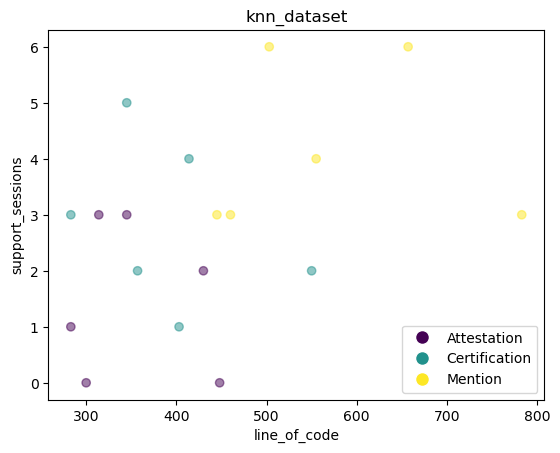

In [27]:
p = scatter_plot(X, Y, Z)
# p.scatter(new_point[0], new_point[1], color='r')
p.show()

### Prediction

Because we choose classification, and our target variable is `categorical`, the prediction output will be the category the new user should assigned to. The prediciton is based on the `k` nearest neighbors. nearest here mean, with the smallest distance.

To compute this prediction, we need to compute the distance between the new point and the data points in the dataset. then we have a list of distances we sort in `descending`order and we take the `k` first elements. The class that is the more represeted in this sub list is our prediction.

##### Algo steps

1. Compute all the distances from all the point of the dataset and the new point
   1. > Don't forget to keep in memory the others informations of the current point (x, y and the class)
2. Sort the list by distances in descending order
   1. > You can use the `sorted` python function, providing the `key` parameter to specify how to sort [doc here](https://www.w3schools.com/python/ref_func_sorted.asp)
3. Select the first `k` eleemnts
4. 4 given the first `k` element, count the class that is represented the most
   1. > maybe think about the `mode` function we did in class :)
  
> **NOTE :** In this dataset, the two variables `lines_of_code` and `support_session` are under very different scale. 
>   - `line of code` is between 300 and 785
>   - `support session` is between 0 and 6
> To make the distance function works weel, we need to same a similar scaling for both variable, for this exercise we'll cheat a bit, you will multiply by `100` the number of support session to have a range between 0 and 600, which is more t^similar to line of code
  

In [28]:
distances = []
lp = 2

for category in data:
  for p in data[category]:
    p = (p[0], p[1]*100)
    q = (new_point[0], new_point[1]*100)
    distance = d(p, q, lp)
    distances.append((distance, category, p))
 
categories = [i for i in sorted(distances, key=lambda x: x[0])[:K]]
print(categories)

prediction = {}
for t in categories:
  prediction[t[1]] = prediction.get(t[1], 0) + 1

print(max(prediction, key=prediction.get))

[(14.0, 'Cert', (414, 400)), (109.65856099730654, 'Mention', (445, 300)), (114.12712210513327, 'A', (345, 300)), (114.12712210513327, 'Cert', (345, 500)), (116.61903789690601, 'Mention', (460, 300))]
Cert


## Bonus Part

### Part 1
Now you predicted the result of this new student. I ask you to display in scatter plot this new student and to draw lines (`plot`) between him and the `k` nearest neighbors. This resulting graph should look like :

![prediction_nei](./imgs/prediction_w_nei.png)

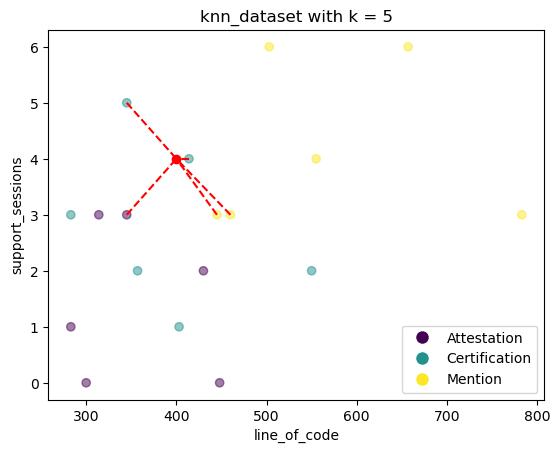

In [29]:
p = scatter_plot(X, Y, Z)
for category in categories[:K]:
  p.plot([category[2][0], new_point[0]], [category[2][1]/100, new_point[1]], color='r', linestyle='dashed')

p.scatter(new_point[0], new_point[1], color='r', marker='o')
p.title(f"knn_dataset with k = {K}")
p.show()

### Part 2

redo, the prediction algorithm, but this time try to change the values of `lp` parameter to see if it's predict differently, if it's not, why ? Try also to display the different neighbors to seee if changing the disstance include differents neighbors, if yes why ?